In [1]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [2]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [3]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [4]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [5]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        # Return True if state is equal to the goal state.
        return state == self.goal
        raise NotImplementedError("Complete GridProblem.is_goal")

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        # Return a list of legal action names.
        #
        # Steps:
        # 1. Create an empty list called legal_actions.
        # 2. For each action in MOVES:
        #       a. Compute the neighbour cell.
        #       b. Check that it is in bounds.
        #       c. Check that it is free.
        #       d. If valid, add the action name to legal_actions.
        # 3. Return legal_actions.
        legal_actions = []
        for action in MOVES:
            dr, dc = MOVES[action]
            row, col = state
            neighbour = (row + dr, col + dc)
            if self.in_bounds(neighbour) and self.is_free(neighbour):
                legal_actions.append(action)
        return legal_actions

        raise NotImplementedError("Complete GridProblem.actions")

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.
        #
        # Hint:
        # dr, dc = MOVES[action]
        # return (row + dr, col + dc)
        dr, dc = MOVES[action]
        row, col = state
        return (row + dr, col + dc)
        raise NotImplementedError("Complete GridProblem.result")

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:
        # In this lab, each valid move has a cost of 1.
        # Return 1.
        return 1
        raise NotImplementedError("Complete GridProblem.action_cost")

In [6]:
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


In [7]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

In [8]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

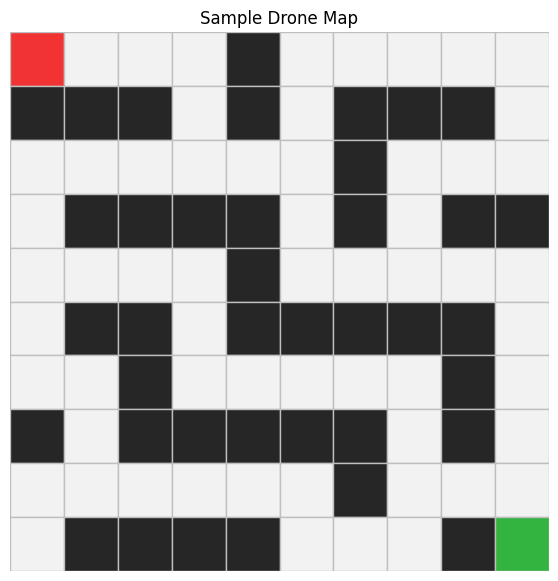

In [9]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")

In [10]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).
        #
        # Pseudocode:
        # s <- node.STATE
        # for each action in problem.ACTIONS(s):
        #     s_prime <- problem.RESULT(s, action)
        #     cost <- node.PATH_COST + problem.ACTION_COST(s, action, s_prime)
        #     yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)

        s = node.state
        for action in problem.actions(s):
            s_prime = problem.result(s, action)
            cost = node.path_cost + problem.action_cost(s, action, s_prime)
            yield Node(state=s_prime, parent=node, action=action, path_cost=cost)

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [11]:
from collections import deque


class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"

        # TODO 6:
        # Implement BFS graph search using a FIFO queue.
        #
        # Steps:
        # 1. Create the initial node from problem.initial_state().
        # 2. If the initial state is the goal, return success.
        # 3. Create a deque frontier and add the initial node.
        # 4. Create a reached set and add the initial state.
        # 5. While frontier is not empty:
        #       a. pop from the LEFT of the deque.
        #       b. increment nodes_expanded.
        #       c. expand the node.
        #       d. for each child:
        #            i. if child is goal, return success.
        #           ii. if child.state is not in reached:
        #                  add child.state to reached.
        #                  append child to frontier.
        #       e. update max_frontier_size.
        # 6. Return failure if no solution is found.
        #
        # Hint:
        # frontier = deque([node])
        # node = frontier.popleft()

        node = Node(state=problem.initial_state())

        if problem.is_goal(node.state):
            return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=node,
                nodes_expanded=0,
                max_frontier_size=0,
            )

        frontier = deque([node])
        reached = {node.state}
        nodes_expanded = 0
        max_frontier_size = 0

        while frontier:
            node = frontier.popleft()
            nodes_expanded += 1

            for child in self.expand(problem, node):
                s = child.state

                if problem.is_goal(s):
                    return SearchResult(
                        algorithm=algorithm,
                        status="success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                    )

                if s not in reached:
                    reached.add(child.state)
                    frontier.append(child)
                    max_frontier_size = max(max_frontier_size, len(frontier))

        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
        )

        raise NotImplementedError("Complete BreadthFirstSearch.search")

In [12]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"

        # TODO 7:
        # Implement DFS graph search using a stack.
        #
        # Steps:
        # 1. Create the initial node.
        # 2. If the initial state is the goal, return success.
        # 3. Use a Python list as the stack frontier.
        # 4. Use a reached set.
        # 5. While frontier is not empty:
        #       a. pop from the end of the list.
        #       b. increment nodes_expanded.
        #       c. expand the node.
        #       d. add unreached children to the stack.
        #       e. update max_frontier_size.
        #
        # Note:
        # If you want DFS to explore actions in the same order as MOVES,
        # you may need to reverse the children before pushing them.

        node = Node(state=problem.initial_state())

        if problem.is_goal(node.state):
            return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=node,
                nodes_expanded=0,
                max_frontier_size=0,
            )

        frontier = [node]
        reached = set()
        nodes_expanded = 0
        max_frontier_size = 0

        while frontier:
            node = frontier.pop()

            if node.state in reached:
                continue

            reached.add(node.state)
            nodes_expanded += 1

            for child in self.expand(problem, node):
                s = child.state

                if problem.is_goal(s):
                    return SearchResult(
                        algorithm=algorithm,
                        status="success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                    )

                if s not in reached:
                    frontier.append(child)
                    max_frontier_size = max(max_frontier_size, len(frontier))

        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
        )

        raise NotImplementedError("Complete DepthFirstSearch.search")

In [13]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:
        # TODO 8:
        # Implement recursive depth-limited search.
        #
        # Steps:
        # 1. If node.state is goal, return (node, "success").
        # 2. Else if node.depth >= limit, return (None, "cutoff").
        # 3. Otherwise:
        #       a. increment metrics["nodes_expanded"].
        #       b. set cutoff_occurred = False.
        #       c. for each child in expand(problem, node):
        #             i. skip the child if child.state already appears on the current path.
        #            ii. update max_stack_size.
        #           iii. recursively call _recursive_dls on the child.
        #            iv. if result is "success", return success immediately.
        #             v. if result is "cutoff", set cutoff_occurred = True.
        #       d. after all children:
        #             if cutoff_occurred, return (None, "cutoff")
        #             else return (None, "failure")

        if problem.is_goal(node.state):
            return (node, "success")

        elif node.depth >= limit:
            return (None, "cutoff")

        else:
            metrics["nodes_expanded"] += 1
            cutoff_occurred = False

            for child in self.expand(problem, node):
                if state_is_on_path(node, child.state):
                    continue

                result, status = self._recursive_dls(
                    problem=problem,
                    node=child,
                    limit=limit,
                    metrics=metrics,
                    current_stack_size=current_stack_size,
                )

                if status == "success":
                    return (result, "success")
                if status == "cutoff":
                    cutoff_occurred = True

            if cutoff_occurred:
                return (None, "cutoff")
            return (None, "failure")

        raise NotImplementedError("Complete DepthLimitedSearch._recursive_dls")

In [14]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        # TODO 9:
        # Implement IDS by repeatedly running DLS from limit 0 to max_depth.
        #
        # Requirements:
        # 1. Keep a list called iteration_log.
        # 2. Accumulate total nodes expanded across all DLS iterations.
        # 3. Track the maximum stack size seen in any DLS run.
        # 4. If a DLS run returns success, return a SearchResult for IDS.
        # 5. If a DLS run returns failure, IDS can stop early and return failure.
        # 6. If all limits return cutoff up to max_depth, return cutoff.
        #
        # Hint:
        # dls = DepthLimitedSearch()
        # result = dls.search(problem, limit=limit)

        iteration_log = []
        total_nodes_expanded = 0
        maximum_stack_size = 0

        dls = DepthLimitedSearch()

        for limit in range(max_depth + 1):
            result = dls.search(problem, limit=limit)

            total_nodes_expanded += result.nodes_expanded
            maximum_stack_size = max(maximum_stack_size, result.max_frontier_size)
            iteration_log.append({"limit": limit, "status": result.status})

            if result.status == "success":
                return SearchResult(
                    algorithm=algorithm,
                    status="success",
                    solution=result.solution,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=maximum_stack_size,
                    iterations=iteration_log,
                )

            if result.status == "failure":
                return SearchResult(
                    algorithm=algorithm,
                    status="failure",
                    solution=None,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=maximum_stack_size,
                    iterations=iteration_log,
                )

        return SearchResult(
            algorithm=algorithm,
            status="cutoff",
            solution=None,
            nodes_expanded=total_nodes_expanded,
            max_frontier_size=maximum_stack_size,
            iterations=iteration_log,
        )

        raise NotImplementedError("Complete IterativeDeepeningSearch.search")


In [15]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=15),
    ids.search(problem, max_depth=30),
]

show_results(results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18.0,18.0,50,5,0
1,DFS,success,NaN,18.0,18.0,18,4,0
2,DLS,cutoff,15.0,NaN,NaN,38,1,0
3,IDS,success,NaN,18.0,18.0,356,1,0


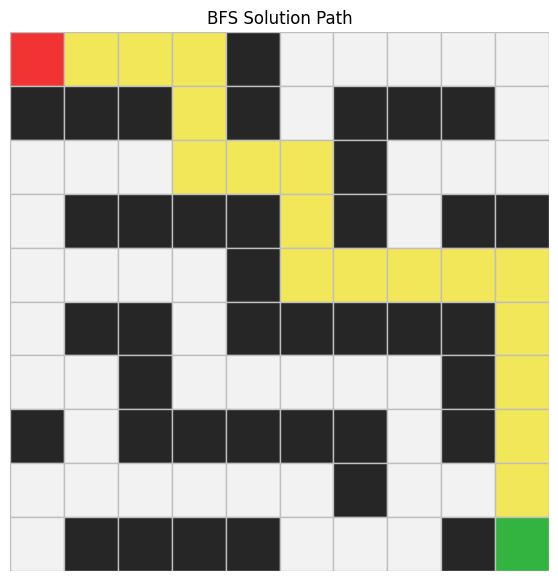

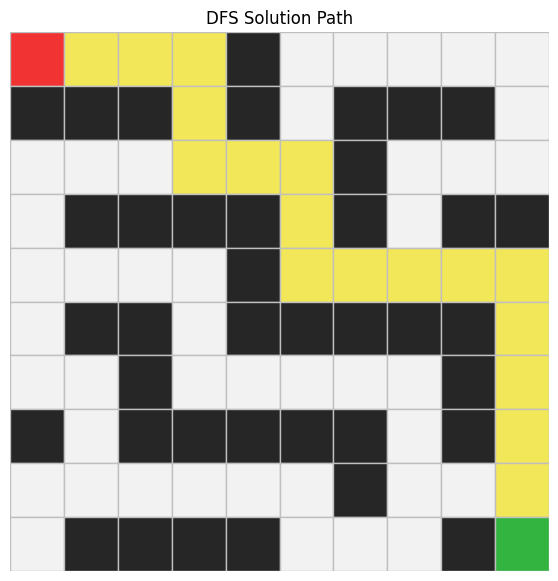

In [16]:
# Visualise solution paths.
# After your algorithms work, choose at least two algorithms and plot their paths.

bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)

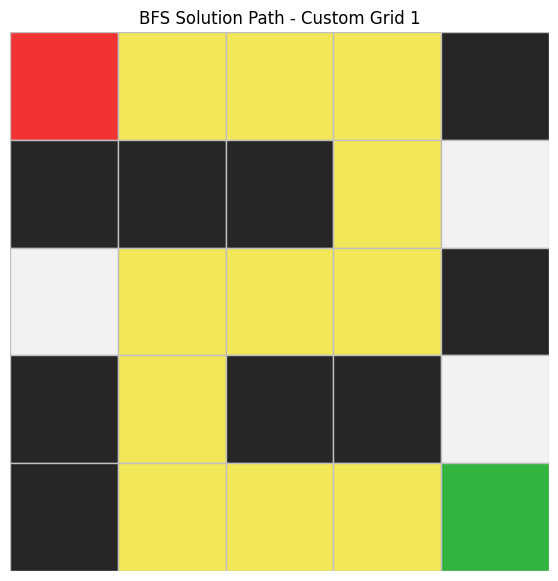

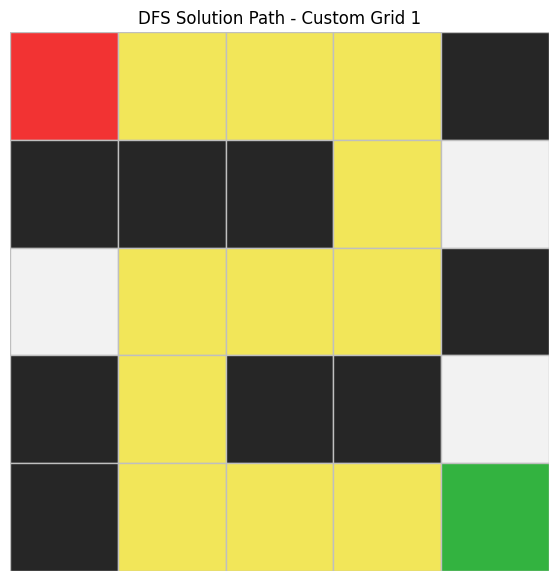

In [17]:
# TODO 10:
# Create your first custom map here.

custom_grid_1 = [
    # Replace this with your own grid.
    [0, 0, 0, 0, 1],
    [1, 1, 1, 0, 0],
    [0, 0, 0, 0, 1],
    [1, 0, 1, 1, 0],
    [1, 0, 0, 0, 0],
]

custom_start_1 = (0, 0)
custom_goal_1 = (4, 4)

# Example after completing:
# custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
# custom_results_1 = [
#     bfs.search(custom_problem_1),
#     dfs.search(custom_problem_1),
#     dls.search(custom_problem_1, limit=20),
#     ids.search(custom_problem_1, max_depth=40),
# ]
# show_results(custom_results_1)

custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=20),
    ids.search(custom_problem_1, max_depth=40),
]
show_results(custom_results_1)

bfs_result_1 = custom_results_1[0]
dfs_result_1 = custom_results_1[1]

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=bfs_result_1.path,
    title="BFS Solution Path - Custom Grid 1",
)
plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=dfs_result_1.path,
    title="DFS Solution Path - Custom Grid 1",
)

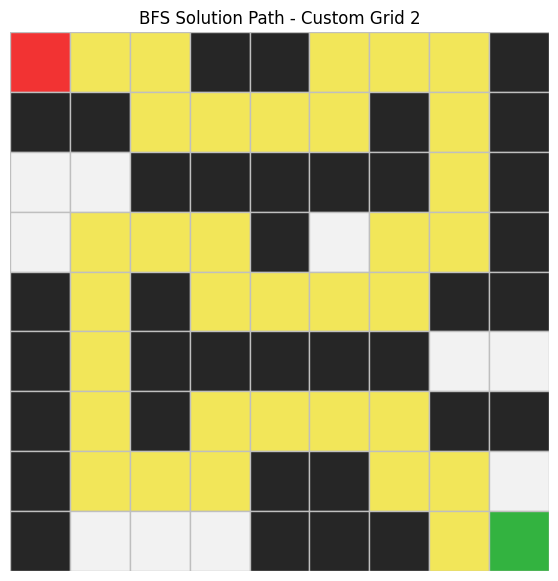

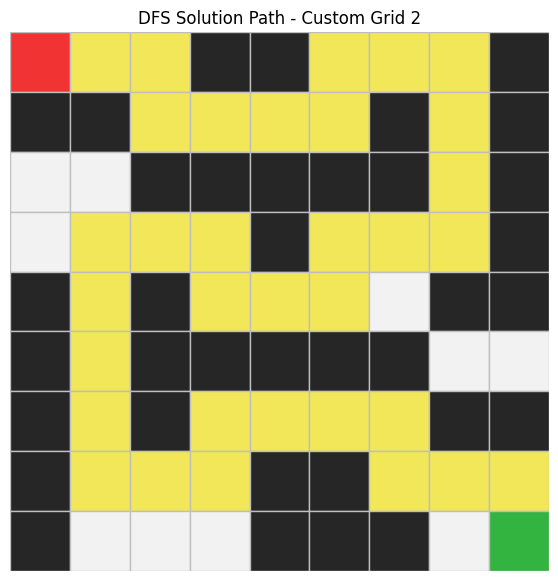

In [18]:
# TODO 11:
# Create your second custom map here.

custom_grid_2 = [
    # Replace this with your own grid.
    [0, 0, 0, 1, 1, 0, 0, 0, 1],
    [1, 1, 0, 0, 0, 0, 1, 0, 1],
    [0, 0, 1, 1, 1, 1, 1, 0, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 1],
    [1, 0, 1, 0, 0, 0, 0, 1, 1],
    [1, 0, 1, 1, 1, 1, 1, 0, 0],
    [1, 0, 1, 0, 0, 0, 0, 1, 1],
    [1, 0, 0, 0, 1, 1, 0, 0, 0],
    [1, 0, 0, 0, 1, 1, 1, 0, 0],
]

custom_start_2 = (0, 0)
custom_goal_2 = (8, 8)

# Example after completing:
# custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
# custom_results_2 = [
#     bfs.search(custom_problem_2),
#     dfs.search(custom_problem_2),
#     dls.search(custom_problem_2, limit=20),
#     ids.search(custom_problem_2, max_depth=40),
# ]
# show_results(custom_results_2)

custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=30),
    ids.search(custom_problem_2, max_depth=50),
]
show_results(custom_results_2)

bfs_result_2 = custom_results_2[0]
dfs_result_2 = custom_results_2[1]

plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=bfs_result_2.path,
    title="BFS Solution Path - Custom Grid 2",
)
plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=dfs_result_2.path,
    title="DFS Solution Path - Custom Grid 2",
)

REFLECTION QUESTIONS

15.1 Problem Formulation
1. A state refers to the current position of the drone on the grid which it is navigating. It is represented as a tuple of its row and column (row, column).

2. An action is the direction in which the drone can move in. (ie. Up, Down, Left, Right)

3. The result function takes in the current state and an action and returns the next state of that node after that specific action is taken.

4. It is necessary to separate the problem definition from the search algorithm because it allows the code to be reused multiple times. The problem can be defined for a different situation and plugged into any of the algorithms to be solved.

15.2 BFS
1. BFS uses a FIFO queue because since nodes are explored level by level, it goes through the first one before it can go any deeper.

2. This is because it explores all the nodes at one level, before going deeper. So by the time it reaches the goal, it would have taken the fewest steps possible.

3. It prevents the algorithm from going to the same cell twice because that can cause an infinite loop.

15.3 DFS
1. It uses a stack because it explored the most recently added nodes first, allowing it to go deeper before backtracking.

2. NO. DFS keeps exploring one path before trying others. So it may explore a longer one which may not lead it to the goal, before backtracking to the right one.

3. DFS uses less memory than BFS when the solution is deep in the tree.

4. It performs badly when the space it is supposed to search in is very deep. It will continue to explore a very long path which does not lead to the goal, before backtracking, which wastes time.

15.4 DLS
1. The algorithm stops searching before reaching the goal because the goal will be deeper than the limit allows.

2. It refers to the exact point where the search is stopeed because it did not find the solution. The solution may exist but is deeper than the allowed limit.

3. DLS is different from DFS because it stops exploring at a specified depth. But DFS keeps exploring until it reaches the goal.

4. We use path-cycle checking to prevent the algorithm from revisiting states already on the current path as this would create an infinite loop.

15.5 IDS
1. IDS repeats DLS with increasing limits because by starting from a depth of 0 and increasing the limit, it assures that it fins the shallowest solution without sorting all the nodes at once.

2. This is because IDS keeps increasing its limit while DLS has a fixed limit. So it keeps increasing the limit until it reaches the goal or reches the final depth.

3. IDS uses less memory because each run only stores the nodes along the current path and not all the nodes at the current level.

4. It is a waste because nodes near the root are re-expanded in every run cycle.

15.6 Real-World Drone Context
1. If one path avoid for example, obstacles, restricted airspace or chooses a path which has a lower risk of signal loss, that path will be more practical compared to others.

2. Breadth-First Search. This is because it guarantees the shortest path when all the paths have an equal cost.

3. Depth-Limited Search. This is because the limit is specified and it prevents the drone from searching beyond that limit.

4. This grid model simplifies the space into a 2D environment. But a real drone navigation will have to deal with wind, varying heights, weather, birds and other dynamic factors which cannot be expressed in the grid form.